In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.signal import find_peaks

from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
from lightkurve import LightCurve
import lightkurve as lk

In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.remove_nans()
lc2_m = lc2.remove_nans().normalize()

In [3]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

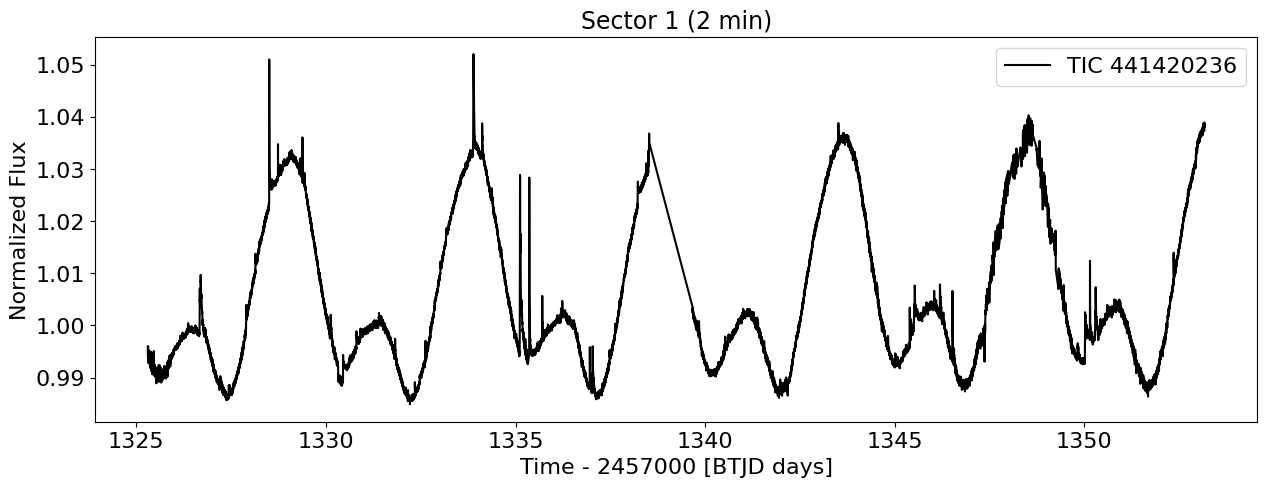

In [4]:

plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Time - 2457000 [BTJD days]').set_fontsize(16)
ax.set_ylabel('Normalized Flux').set_fontsize(16)  
plt.title('Sector 1 (2 min)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [5]:
########### FLATTEN NOVO ##################

vetores = [
    [1326.6711, 1326.7794],
    [1327.8929, 1327.9763],
    [1328.4985, 1328.5822],
    [1328.4130, 1328,690],
    [1328.7326, 1328.7474],
    [1329.3756, 1329.4123],
    [1330.1210, 1330.1377],
    [1330.4496, 1330.5464],
    [1331.8210, 1331.8574],
    [1333.8797, 1333.9809],
    [1334.1134, 1334.1507],
    [1335.1052, 1335.2524],
    [1335.3517, 1335.4232],
    [1335.7022, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0633],
    [1338.2201, 1338.2396],
    [1338.4973, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914, 1345.4122],
    [1345.3918, 1345.4119],
    [1345.5044, 1345.5562],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1350.0068, 1350.0502],
    [1350.1441, 1350.3345],
    [1350.2795, 1350.3247],
    [1330.3039, 1330.4724],
    [1347.3173, 1347.3250],
    [1342.2240, 1342.2398],
    [1352.3514, 1352.3619],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1345.3926, 1345.4123],
    [1350.2720, 1350.3608],
    [1350.0112, 1350.4109],
    [1349.2727, 1349.3229],
]

vetor_true = [False]*len(x2min)



for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

In [6]:
valores = [
    [1326.6645, 1326.8041],
    [1327.8932, 1327.9330],
    [1328.5027, 1328.7611],
    [1329.3765, 1329.4061],
    [1330.1159, 1330.1677],
    [1330.3149, 1330.4541],
    [1331.8200, 1331.8671],
    [1333.8795, 1333.9640],
    [1334.1140, 1334.1528],
    [1335.1052, 1335.2529],
    [1335.3517, 1335.4065],
    [1335.7001, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0795],
    [1338.2217, 1338.3009],
    [1338.4965, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914,1345.4589],
    [1347.2744, 1347.3911],
    [1347.2744, 1347.3911],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1350.0068, 1350.1396],
    [1350.1436, 1350.1649],
    [1350.2795, 1350.3477],
    [1352.3507, 1352.3648]
]

valores_true = [False]*len(x2min)


for j in range(len(x2min)):
    for i in range(len(valores)):
        if (x2min[j]>=valores[i][0]) and (x2min[j]<=valores[i][1]):
            valores_true[j] = True

mascara_1 = np.array(valores_true)


In [7]:
flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
tempo_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
fluxo_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)

In [8]:
#Recortando e ajeitando ainda mais a normalização 
xdefinitivo2 = []
ydefinitivo2 = []
for j in range(len(y2min)):
    if 1328.38895 < x2min[j] < 1328.79932:
        xdefinitivo2.append(x2min[j])
        ydefinitivo2.append(y2min[j])

xdefinitivo2 = np.array(xdefinitivo2)
ydefinitivo2 = np.array(ydefinitivo2)

vetores1 = [
    [1328.4985, 1328.666],
    [1328.729,2328.784]
]
vetor_true1 = [False]*len(xdefinitivo2)

for j in range(len(xdefinitivo2)):
    for i in range(len(vetores1)):
        if (xdefinitivo2[j]>=vetores1[i][0]) and (xdefinitivo2[j]<=vetores1[i][1]):
            vetor_true1[j] = True

mascara1 = np.array(vetor_true1)

lc =  LightCurve(time=xdefinitivo2, flux=ydefinitivo2)
flcd2 = lc.flatten(window_length=30, polyorder=1, return_trend=False, break_tolerance=10, niters=2, sigma=2.5, mask=mascara1)


detrended_lc = flcd2

tempo_detrend1 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend1 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

#################################################################################################################
xdefinitivo3 = []
ydefinitivo3 = []
for j in range(len(y2min)):
    if 1338.146329 < x2min[j] < 1338.322494:
        xdefinitivo3.append(x2min[j])
        ydefinitivo3.append(y2min[j])

xdefinitivo3 = np.array(xdefinitivo3)
ydefinitivo3 = np.array(ydefinitivo3)

vetores2 = [
    [1338.2152,1338.3017]
]
vetor_true2 = [False]*len(xdefinitivo3)

for j in range(len(xdefinitivo3)):
    for i in range(len(vetores2)):
        if (xdefinitivo3[j]>=vetores2[i][0]) and (xdefinitivo3[j]<=vetores2[i][1]):
            vetor_true2[j] = True

mascara3 = np.array(vetor_true2)

lc2 =  LightCurve(time=xdefinitivo3, flux=ydefinitivo3)
flcd3 = lc2.flatten(window_length=35, polyorder=1, return_trend=False, break_tolerance=10, niters=3, sigma=2.5, mask=mascara3)

detrended_lc = flcd3

tempo_detrend3 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend3 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

##########################################################################################################
xdefinitivo4 = []
ydefinitivo4 = []
for j in range(len(y2min)):
    if 1347.9821 < x2min[j] < 1349.4213:
        xdefinitivo4.append(x2min[j])
        ydefinitivo4.append(y2min[j])

xdefinitivo4 = np.array(xdefinitivo4)
ydefinitivo4 = np.array(ydefinitivo4)



lc4 =  LightCurve(time=xdefinitivo4, flux=ydefinitivo4)
flcd4 = lc4.flatten(window_length=250, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=None)

detrended_lc = flcd4

tempo_detrend4 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend4 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

##############################################################################################################################################################

xdefinitivo5 = []
ydefinitivo5 = []
for j in range(len(y2min)):
    if 1345.3085 < x2min[j] < 1345.6397:
        xdefinitivo5.append(x2min[j])
        ydefinitivo5.append(y2min[j])


xdefinitivo5 = np.array(xdefinitivo5)
ydefinitivo5 = np.array(ydefinitivo5)

vetores3 = [
    [1345.3886,1345.4579],
    [1345.4992,1345.6308]
]
vetor_true3 = [False]*len(xdefinitivo5)

for j in range(len(xdefinitivo5)):
    for i in range(len(vetores3)):
        if (xdefinitivo5[j]>=vetores3[i][0]) and (xdefinitivo5[j]<=vetores3[i][1]):
            vetor_true3[j] = True

mascara5 = np.array(vetor_true3)


lc5 =  LightCurve(time=xdefinitivo5, flux=ydefinitivo5)
flcd5 = lc5.flatten(window_length=30, polyorder=1, return_trend=False, break_tolerance=6, niters=3, sigma=2.5, mask=mascara5)

detrended_lc = flcd5

tempo_detrend5 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend5 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)





#########################################################################################################################################################################
########### O FOR PARA O CORTE DOS VALORES QUE ESTÃO COM NORMALIZAÇÃO RUIM E ADICIONAR NA NORMALIZAÇÃO MELHOR############################
count = 0
count1 = 0
count2 = 0
count3 = 0

for j in range(len(tempo_detrend)):
    if tempo_detrend[j]>=1328.38895 and  tempo_detrend[j]<=1328.79932:
       fluxo_detrend[j]= fluxo_detrend1[count]
       tempo_detrend[j]= tempo_detrend1[count]
       count = count + 1
    if tempo_detrend[j]>=1338.146329 and  tempo_detrend[j]<=1338.322494:
       fluxo_detrend[j]= fluxo_detrend3[count1]
       tempo_detrend[j]= tempo_detrend3[count1]
       count1 = count1 + 1
    if tempo_detrend[j]>= 1347.9821 and  tempo_detrend[j]<=1349.4213:
       fluxo_detrend[j]= fluxo_detrend4[count2]
       tempo_detrend[j]= tempo_detrend4[count2]
       count2 = count2 + 1
    if tempo_detrend[j]>= 1345.3085 and  tempo_detrend[j]<=1345.6397:
       fluxo_detrend[j]= fluxo_detrend5[count3]
       tempo_detrend[j]= tempo_detrend5[count3]
       count3 = count3 + 1
   

In [9]:
x_detrend = []
y_detrend = []
for j in range(len(mascara_1)):
    if  mascara_1[j] == False:
        y_detrend.append(fluxo_detrend[j])
        x_detrend.append(tempo_detrend[j])
mascara2 = [False]*len(mascara_1)

In [13]:
#Calculando a média simples dos dados 

y_mean = np.mean(y_detrend)
#Media para todos os pontos do eixo x, para apresentar no grafico 
#y_mean2 = [y_mean for i in range(len(y))]
y_mean2 = [y_mean]*len(y_detrend)
#Calculo do desvio padrao dos dados
desvio = (np.std(y_detrend))
#print(y_mean)
#Media mais desvio padrao
med_desv = y_mean2+desvio

#Corte nos valores de média+ 2*sigma

med_desv2 = y_mean + (2*desvio)
med_desv3 = y_mean - (2*desvio)
xdefinitivo = []
ydefinitivo = []
for j in range(len(y_detrend)):
    if y_detrend[j] < med_desv2 and y_detrend[j]>med_desv3:
        ydefinitivo.append(y_detrend[j])
        xdefinitivo.append(x_detrend[j])
xdefinitivo = np.array(xdefinitivo)
ydefinitivo = np.array(ydefinitivo)

#Calculo novo da média e do desvio padrão do ruido 
y_m = np.mean(ydefinitivo)
y_m2 = [y_m]*len(ydefinitivo)
desvio2 = (np.std(ydefinitivo))
med = y_m2 + desvio2
med2 = y_m +3*desvio2
print(desvio2)

0.0004128926865930232


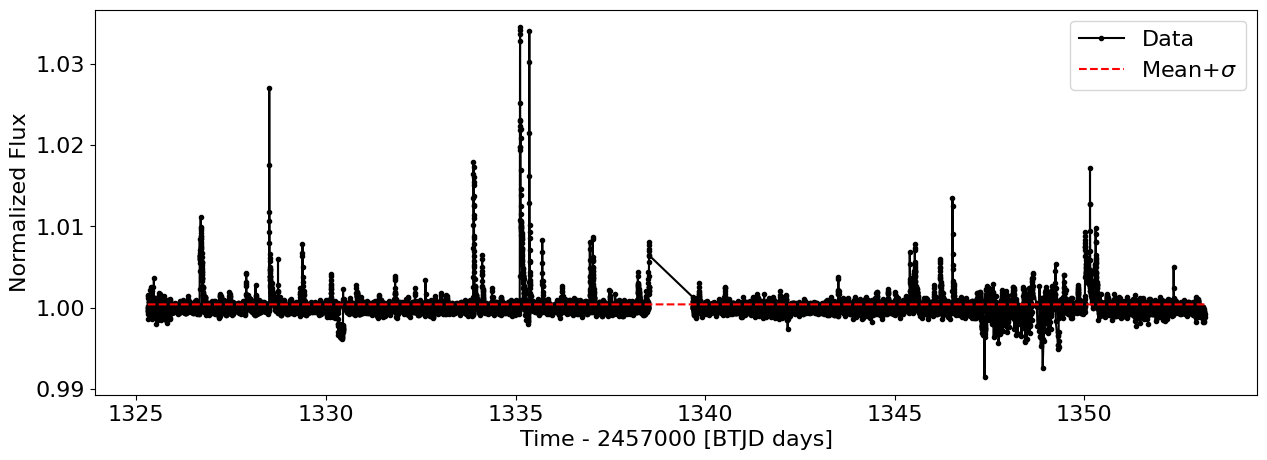

In [15]:
plt.rcParams['font.size'] = 16
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

# Plot the data
data_line = ax.plot(tempo_detrend, fluxo_detrend, marker='.', color='black', label='Data')

# Plote a linha tracejada da média
ax.plot(xdefinitivo, med, label='Mean+$\sigma$', linestyle='--', color='red')


legend = ax.legend(loc='upper right')
ax.set(xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux', rasterized=True)
plt.show()

In [16]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from scipy.signal import find_peaks
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
from lightkurve import LightCurve
import lightkurve as lk

search_result = search_lightcurve("AU Mic") 
lc2min = search_result[8].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

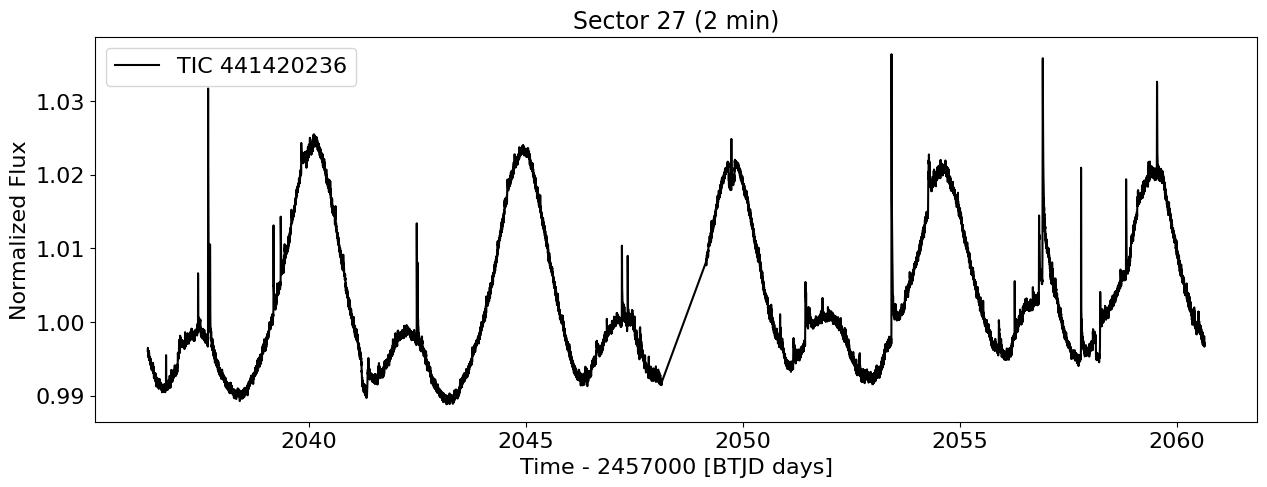

In [18]:

plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Time - 2457000 [BTJD days]').set_fontsize(16)
ax.set_ylabel('Normalized Flux').set_fontsize(16)  
plt.title('Sector 27 (2 min)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [19]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

search_result = search_lightcurve("AU Mic") 
lc2min = search_result[7].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.normalize().remove_nans()

x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

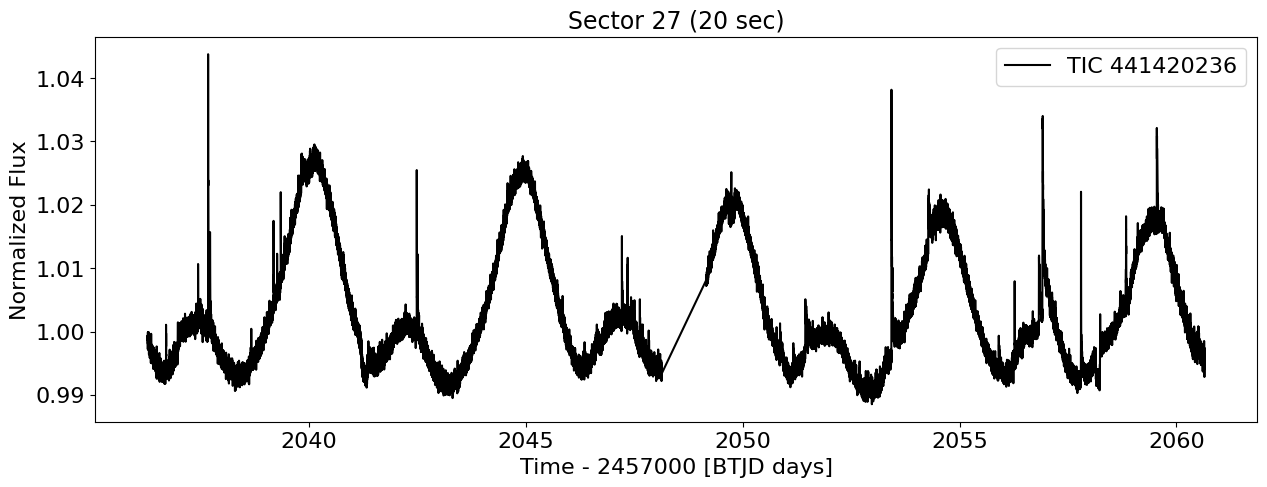

In [21]:

plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Time - 2457000 [BTJD days]').set_fontsize(16)
ax.set_ylabel('Normalized Flux').set_fontsize(16)  
plt.title('Sector 27 (20 sec)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()